In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pybamm
import scipy
import sys
sys.path.append('..')  # or sys.path.insert(0, '..')
import plot_settings
plot_settings.apply()

import importlib
import sim_PyBaMM
import exp_pybamm
importlib.reload(exp_pybamm)

<module 'exp_pybamm' from '/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/ECM/../exp_pybamm.py'>

In [12]:
# Polynomial function for OC voltage vs SOC (example coefficients)
def V_soc_poly(soc, coeffs):
    p = np.poly1d(coeffs)
    # return np.polyval(coeffs, soc)
    return p(soc)

def step(state, I, p, coeffs):
    soc, U1 = state

    # Voltage at current state
    V_soc = V_soc_poly(soc, coeffs)
    V = V_soc - I*p['R0'] - U1

    # Evolve state
    soc_new = soc - (I * p['dt'] / p['Q'])
    U1_new = p['a']*U1 + p['R1']*(1 - p['a'])*I
    
    return (soc_new, U1_new), V, V_soc

def simulation(p, coeffs):
    # initial state
    state = (1.0, 0.0)
    soc = state[0]
    U1 = state[1]
    
    time = []
    I_list = []
    soc_list = []
    U1_list = []
    V_list = []
    V_soc_list = []
    
    t = 0
    while soc > 0:
        I = current_profile(t)
        time.append(t)
        I_list.append(I)
        soc_list.append(soc)
        U1_list.append(U1)
        
        # Calculate voltage at current state
        V_soc = V_soc_poly(soc, coeffs)
        V = V_soc - I*p['R0'] - U1
        V_list.append(V)
        V_soc_list.append(V_soc)

        # Update state
        state, _, _ = step(state, I, p, coeffs)
        soc, U1 = state

        t += p['dt']

    return time, I_list, soc_list, U1_list, V_list, V_soc_list


In [3]:
def simulate_pybamm():
    model = pybamm.lithium_ion.SPM()
    param = model.default_parameter_values
    def my_current(t):
        return current_profile_pybamm(t)
    
    param["Current function [A]"] = my_current

    param.process_model(model)
    geometry = model.default_geometry
    param.process_geometry(geometry)
    mesh = pybamm.Mesh(geometry, model.default_submesh_types, model.default_var_pts)
    disc = pybamm.Discretisation(mesh, model.default_spatial_methods)
    disc.process_model(model)
    t_eval = [0,3*3600]

    solver = pybamm.IDAKLUSolver(atol=1e-6, rtol=1e-3)
    solution = solver.solve(model, t_eval)

    npc_v = solution.observe(model.variables['Voltage [V]'])
    npc = solution.observe(model.variables['Battery open-circuit voltage [V]'])
    npc_soc = solution.observe(model.variables['Average negative particle concentration'])
    npc_I = solution.observe(model.variables['Current variable [A]'])
    return solution,model, npc_v, npc, npc_soc, npc_I

def fit_func(solution, npc):
    t_ = np.linspace(0,solution['Time [s]'].entries[-1], 101)
    coeffs_ = np.polyfit(np.linspace(1,0,101), npc(t_), 10)  # Assumes pybamm soc [1, 0]
    poly = np.poly1d(coeffs_)  # Create polynomial function
    return poly, coeffs_, t_


/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/venv/lib/python3.12/site-packages/pybamm/solvers/base_solver.py:1008: SolverWarning: While solving Single Particle Model extrapolation occurred for ["Interpolant 'interpolating_function' upper bound"]
  self.check_extrapolation(solution, model.events)


[ 3.15845444e+02 -1.55679646e+03  3.16018260e+03 -3.32336545e+03
  1.78576170e+03 -2.79658643e+02 -1.95143832e+02  1.14747786e+02
 -2.33669284e+01  2.01423200e+00  3.63176026e+00]


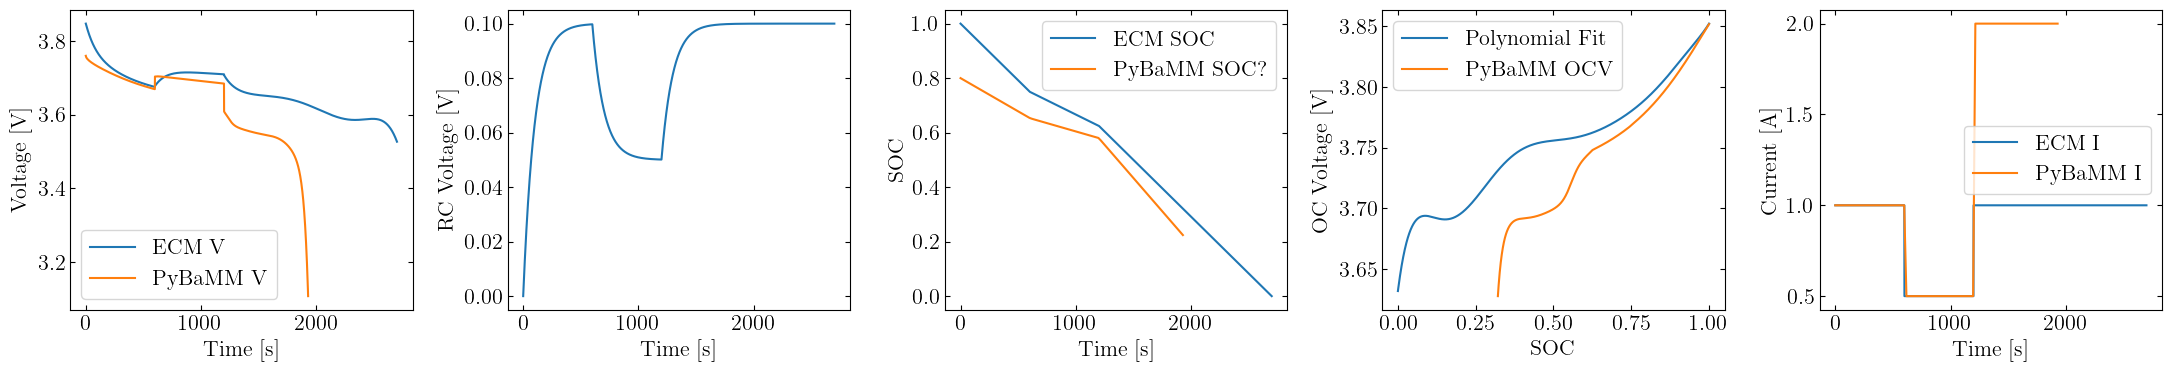

In [ ]:
# Parameters
params = dict(
    R0=0.005, # Ohm
    R1=0.1, # Ohm
    C1=1000, # F
    dt=1, # time step in seconds
    # I0=1. # Current in A
)
params['Q'] = 2400 # Capacity in As (1Ah = 3600 As)
# params['Q'] = params['I0'] * params['t_tot'] # Capacity in As (1Ah = 3600 As)
params['a'] = np.exp(-params['dt'] / (params['R1'] * params['C1'])) # Time constant for the RC circuit


def current_profile(t):
    if t < 600:
        return 1
    elif t < 1200:
        return 0.5
    else:
        return 1


def current_profile_pybamm(t):

    times = np.array([0, 600, 600, 1200, 1200, 1300])
    values = np.array([1, 1, 0.5, 0.5, 2, 2])

    I = pybamm.Interpolant(times, values, pybamm.t)
    return I



# PyBaMM
solution, model, npc_v, npc, npc_soc, npc_I = simulate_pybamm()
poly, coeffs_, t_ = fit_func(solution, npc)
print(coeffs_)
# ECM
time, I, soc, U1, V, V_soc = simulation(p=params, coeffs=coeffs_)

# Plotting
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(22, 4))
ax1.plot(time, V, label='ECM V')
ax1.plot(time, npc_v(time), label='PyBaMM V')
ax1.legend()
ax1.set_ylabel('Voltage [V]')
ax1.set_xlabel('Time [s]')
ax2.plot(time, U1, label='RC Voltage [V]')
ax2.set_ylabel('RC Voltage [V]')
ax2.set_xlabel('Time [s]')
ax3.plot(time, soc, label='ECM SOC')
# ax3.plot(t_, npc_soc(t_), label='PyBaMM SOC?')
ax3.legend()
ax3.set_ylabel('SOC')
ax3.set_xlabel('Time [s]')
ax4.plot(soc, poly(soc), label='Polynomial Fit')
ax4.plot(soc, npc(time), label='PyBaMM OCV')
ax4.set_xlabel('SOC')
ax4.set_ylabel('OC Voltage [V]')
ax4.legend()
ax5.plot(time, I, label='ECM I')
ax5.plot(t_, npc_I(t_), label='PyBaMM I')
ax5.legend()
ax5.set_xlabel('Time [s]')
ax5.set_ylabel('Current [A]')
plt.tight_layout()

# print(soc, npc(time).shape)

# [ 2.88142415e+02 -1.55657563e+03  3.61453979e+03 -4.70566575e+03
#   3.75473052e+03 -1.88761431e+03  5.95964726e+02 -1.17137211e+02
#   1.50781176e+01 -1.42962362e+00  3.81920394e+00]

# [ 3.15845444e+02 -1.55679646e+03  3.16018260e+03 -3.32336545e+03
#   1.78576170e+03 -2.79658643e+02 -1.95143832e+02  1.14747786e+02
#  -2.33669284e+01  2.01423200e+00  3.63176026e+00]

In [68]:
t, t_eval, i_pybamm, V_pybamm = exp_pybamm.get_values()
print(t.shape, i_pybamm.shape)

2026-02-12 12:45:48.753 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Minimum voltage [V]' was triggered during 'Discharge at 2.472359298710189C for 249 seconds'. The returned solution only contains up to step 1 of cycle 29. 


(1000,) (1000,)


In [ ]:
def current_scalar(t_scalar):
    return np.interp(t_scalar, t, i_pybamm)

def dU(u, t_scalar, p):
    I_t = current_scalar(t_scalar)
    return -u / (p['R1'] * p['C1']) + I_t / p['C1']

def soc_dot(z, t_scalar, p):
    I_t = current_scalar(t_scalar)
    return -I_t / p['Q']

def model_II(p, coeffs):

    # Solve ODEs on SAME grid t
    U_sol = scipy.integrate.odeint(dU, 0.0, t, args=(p,))
    soc_sol = scipy.integrate.odeint(soc_dot, 1.0, t, args=(p,))

    U = U_sol.flatten()
    soc = soc_sol.flatten()

    # Compute voltage using same time grid
    V_model = (V_soc_poly(soc, coeffs) - i_pybamm * p['R0'] - U)

    return V_model

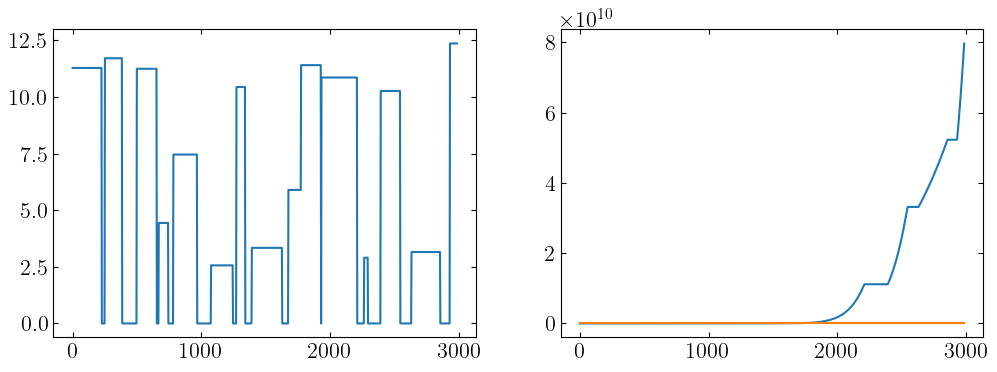

In [67]:
V_model = model_II(params, coeffs_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# ax1.plot(t_eval, i_model)
ax1.plot(t, i_pybamm)
ax2.plot(t, V_model)
ax2.plot(t, V_pybamm)

## Bayes

In [7]:
u_obs = npc_v(time)

In [8]:
import scipy.stats as stats
import corner
import emcee


def simulate_II(R1, C1, p=params, coeffs=coeffs_):
    time, I_list, soc_list, U1_list, V_list, V_soc_list = simulation(p, coeffs)
    return V_list

def model_II(theta):
    R1,C1 = theta
    U = simulate_II(R1,C1)[1]
    return U 


def log_prior_II(theta):
    R1,C1 = theta

    R1_lims = (0.01, 1e4)
    C1_lims = (1, 100000)
    p_R1 = stats.uniform.logpdf(R1, loc=R1_lims[0], scale=R1_lims[1] - R1_lims[0])
    p_C1 = stats.uniform.logpdf(C1, loc=C1_lims[0], scale=C1_lims[1] - C1_lims[0])

    #if R0 < R0_lims[0] or R0 > R0_lims[1] or R1 < R1_lims[0] or R1 > R1_lims[1] or or R2 > R2_lims[1] or C1 < C1_lims[0] or C1 > C1_lims[1] or C2 < C2_lims[0] or C2 > C2_lims[1]:
    #    return -np.inf  # Log of zero probability for out-of-bounds parameters
    
    return p_R1 + p_C1 

def log_likelihood_II(theta, U_obs = u_obs):
    U_model = model_II(theta)
    sigma = 0.01  # Assumed standard deviation of the noise
    return stats.norm.logpdf(U_model - U_obs, loc=0, scale=sigma).sum()

def log_posterior_II(theta):
    log_post = log_likelihood_II(theta) + log_prior_II(theta)
    
    if np.isnan(log_post):
        return -np.inf
    
    return log_post

In [9]:
def samples_MCMC_II(post,nwalkers = 50, burninproc =10 , iterations = 100):
    """
    Sets up an MCMC sampler with initial positions for the walkers.

    Args:
        theta_0_lims (list): Minimum and maximum boundary for starting position in theta0.
        theta_1_lims (list): Minimum and maximum boundary for starting position in theta1.
        x (array): Independent data.
        y (array): Dependent data.
        post (callable): Function to compute the log-posterior or log-likelihood.
        nwalkers (int): Number of MCMC walkers.

    Returns:
        sampler (emcee.EnsembleSampler): Initialized MCMC sampler object.
    """
    
    ndim = 2  # Since theta has three parameters:

    rng = np.random.default_rng(seed = 1337)

    R_lims = (0.01, 1e4)
    C_lims = (1, 100000)
    R1   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    #R2   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    C1   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)
    #C2   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)

    p0 = np.vstack((R1,C1)).T

    burnin = int(burninproc*iterations/100)

    # Set up the MCMC sampler with the log posterior function
    sampler_post = emcee.EnsembleSampler(nwalkers, ndim, post)
    new_pos, prob, state = sampler_post.run_mcmc(p0, burnin, progress=True)

    run = sampler_post.run_mcmc(new_pos, iterations, progress=True)
    samples = sampler_post.get_chain(flat = True)

    return samples

In [10]:
samples = samples_MCMC_II(log_posterior_II)

 18%|█▊        | 18/100 [01:07<05:15,  3.85s/it]Traceback (most recent call last):
  File "/Users/noord/Library/CloudStorage/OneDrive-Chalmers/Master2/MSc_thesis/program/venv/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_1565/399865054.py", line 35, in log_posterior_II
    log_post = log_likelihood_II(theta) + log_prior_II(theta)
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_1565/399865054.py", line 30, in log_likelihood_II
    U_model = model_II(theta)
              ^^^^^^^^^^^^^^^
  File "/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_1565/399865054.py", line 12, in model_II
    U = simulate_II(R1,C1)[1]
        ^^^^^^^^^^^^^^^^^^
  File "/var/folders/cc/g7htxfj57sq65d7g1185yzwr0000gn/T/ipykernel_1565/399865054.py", line 7, in 

emcee: Exception while calling your likelihood function:
  params: [ 3328.68111121 55749.98905249]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

In [ ]:
burned_samples = samples[:10 * len(samples) // 100] 
samples = samples[10 * len(samples) // 100:]

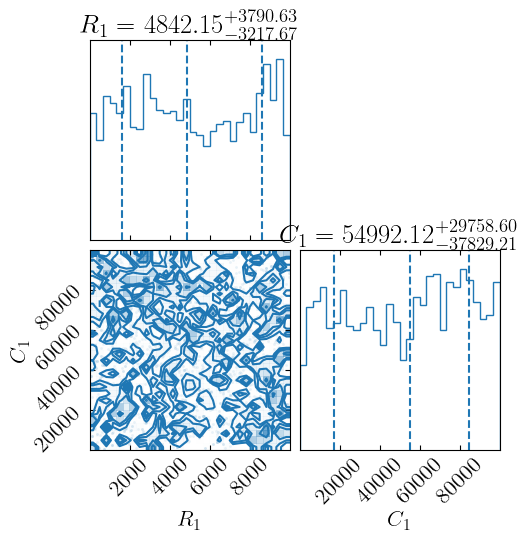

In [ ]:
fig = corner.corner(samples, labels=[r"$R_1$",r"$C_1$"], color='tab:blue',
                show_titles=True, bins=30, plot_contours=True, plot_datapoints=True, 
                plot_density=True,quantiles=[0.16,0.5,0.84])